In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import relu,linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

In [3]:
def gen_data(m, seed=1, scale=0.7):
    """ generate a data set based on a x^2 with added noise """
    c = 0
    x_train = np.linspace(0,49,m)
    np.random.seed(seed)
    y_ideal = x_train**2 + c
    y_train = y_ideal + scale * y_ideal*(np.random.sample((m,))-0.5)
    x_ideal = x_train #for redraw when new data included in X
    return x_train, y_train, x_ideal, y_ideal

In [4]:
# Generate some data
X,y,x_ideal,y_ideal = gen_data(18, 2, 0.7)
print("X.shape", X.shape, "y.shape", y.shape)

#split the data using sklearn routine
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_test.shape", X_test.shape, "y_test.shape", y_test.shape)

X.shape (18,) y.shape (18,)
X_train.shape (12,) y_train.shape (12,)
X_test.shape (6,) y_test.shape (6,)


# EXO1 :

In [7]:
def eval_mse(y, yhat):
  
  m = y.shape[0]
  err = np.sum((yhat - y) ** 2) / (2 * m)
  
  return err


In [8]:
y_hat = np.array([2.4, 4.2])
y_tmp = np.array([2.3, 4.1])
print("err =",eval_mse(y_hat, y_tmp))

err = 0.0050000000000000305


# EXO2 :

In [ ]:
# reshape input data
X_train_mapped = X_train.reshape(-1, 1) 
X_test_mapped = X_test.reshape(-1, 1)

# create polynomial features :
poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train_mapped) 
X_test_poly = poly.transform(X_test_mapped) 

# scale features : 
scaler = StandardScaler() 
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

# train model
model = LinearRegression()
model.fit(X_train_poly_scaled, y_train)

# predictions
yhat_train = model.predict(X_train_poly_scaled)
yhat_test = model.predict(X_test_poly_scaled)

# errors
train_error = eval_mse(y_train, yhat_train)
test_error = eval_mse(y_test, yhat_test)

In [10]:
print(f"training err {train_error:0.2f}, test err {test_error:0.2f}")

training err 58.01, test err 171215.01


# conclusion : 
- training error is small, but testing error is huge !
- this is overfitting ! 10 degree is so much

# solution ?
- add samples !
- reduce model complexity
- regularization ? (i think it won't help, since we our nbr of samples is low)

In [11]:
# Generate  data
X,y, x_ideal,y_ideal = gen_data(40, 5, 0.7)

X_test = np.linspace(0,int(X.max()),100)
print("X.shape", X.shape, "y.shape", y.shape)

#split the data using sklearn routine
X_train, X_cv, y_train, y_cv = train_test_split(X,y,test_size=0.40, random_state=1)
print("X_train.shape", X_train.shape, "y_train.shape", y_train.shape)
print("X_cv.shape", X_cv.shape, "y_cv.shape", y_cv.shape)

X.shape (40,) y.shape (40,)
X_train.shape (24,) y_train.shape (24,)
X_cv.shape (16,) y_cv.shape (16,)


# EXO3 :

In [19]:
max_degree = 9
err_train = np.zeros(max_degree)
err_cv = np.zeros(max_degree)

y_pred = np.zeros((100,max_degree))  #columns are lines to plot

scalar = StandardScaler()

for degree in range(max_degree):
    ##CODE STARTS HERE##

    poly = PolynomialFeatures(degree=degree+1, include_bias=False)

    x_train_poly = poly.fit_transform(X_train.reshape(-1,1))
    x_cv_poly = poly.transform(X_cv.reshape(-1,1))

    scalar = StandardScaler()
    x_train_poly = scalar.fit_transform(x_train_poly)
    x_cv_poly = scalar.transform(x_cv_poly)

    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    yhat_train = model.predict(x_train_poly)
    yhat_cv = model.predict(x_cv_poly)

    err_train[degree] = eval_mse(y_train, yhat_train)
    err_cv[degree] = eval_mse(y_cv, yhat_cv)

    ##CODE ENDS HERE##

    x_poly = poly.transform(X_test.reshape(-1,1))
    x_poly = scalar.transform(x_poly)
    y_pred[:,degree] = model.predict(x_poly)

optimal_degree = np.argmin(err_cv)+1  ## test on **cv data** !!
print("optimal degree =", optimal_degree)

optimal degree = 3


In [14]:
def plt_optimal_degree(X_train, y_train, X_cv, y_cv, x, y_pred, x_ideal, y_ideal, err_train, err_cv, optimal_degree, max_degree):
    # Plot predictions vs data for each degree in separate figures
    for i in range(max_degree):
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        fig.canvas.toolbar_visible = False
        fig.canvas.header_visible = False
        fig.canvas.footer_visible = False

        # Plot predictions vs data
        ax[0].set_title(f"Predictions vs Data (Degree {i+1})", fontsize=12)
        ax[0].set_xlabel("x")
        ax[0].set_ylabel("y")

        ax[0].plot(x_ideal, y_ideal, "--", color="orangered", label="y_ideal", lw=1)
        ax[0].scatter(X_train, y_train, color="red", label="train")
        ax[0].scatter(X_cv, y_cv, color="orange", label="cv")
        ax[0].plot(x, y_pred[:, i], lw=1, label=f"Degree {i+1}")
        ax[0].legend(loc='upper left')

        # Plot error vs degree
        ax[1].set_title("Error vs Degree", fontsize=12)
        cpts = list(range(1, max_degree + 1))
        ax[1].plot(cpts, err_train[0:], marker='o', label="train error", lw=2, color="blue")
        ax[1].plot(cpts, err_cv[0:], marker='o', label="cv error", lw=2, color="orange")
        ax[1].axvline(x=i+1, color="red", linestyle="--", lw=1, label=f"Degree {i+1}")
        ax[1].set_xlabel("degree")
        ax[1].set_ylabel("error")
        ax[1].legend()

        fig.suptitle(f"Degree {i+1}: Predictions and Errors", fontsize=12)
        plt.tight_layout()
        plt.show()

    fig.suptitle("Find Optimal Degree", fontsize=12)
    plt.tight_layout()
    plt.show()

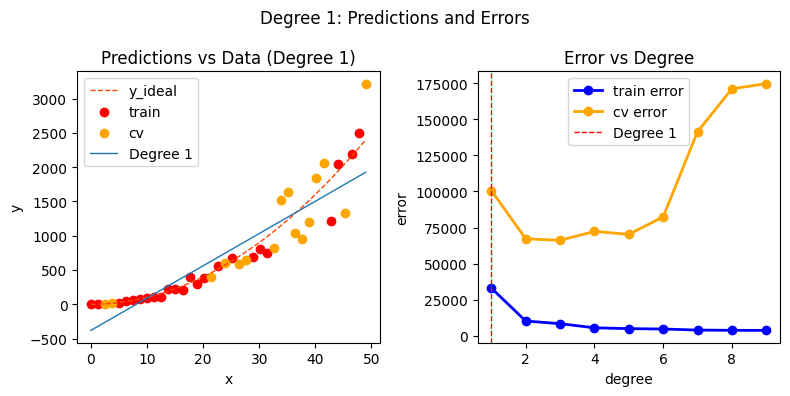

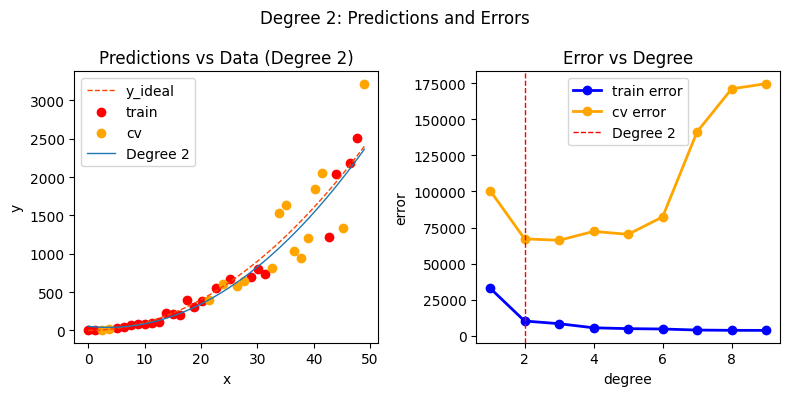

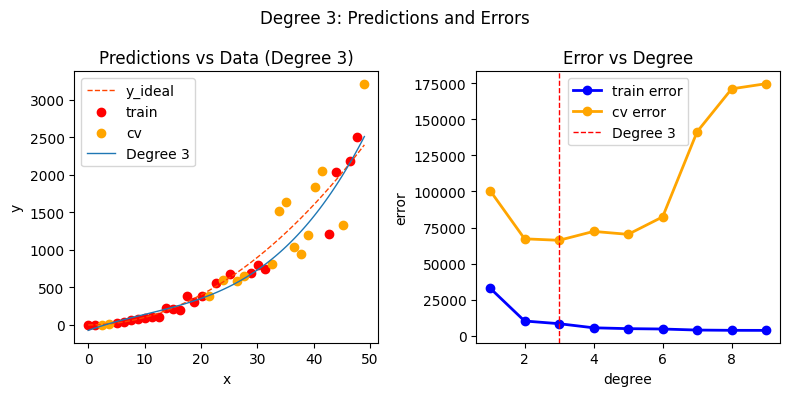

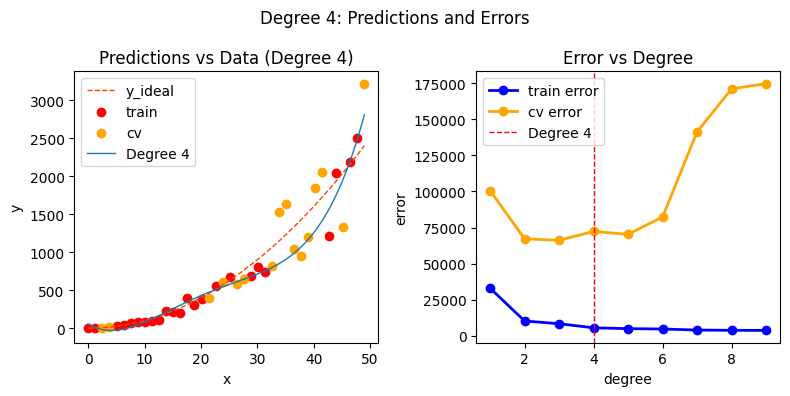

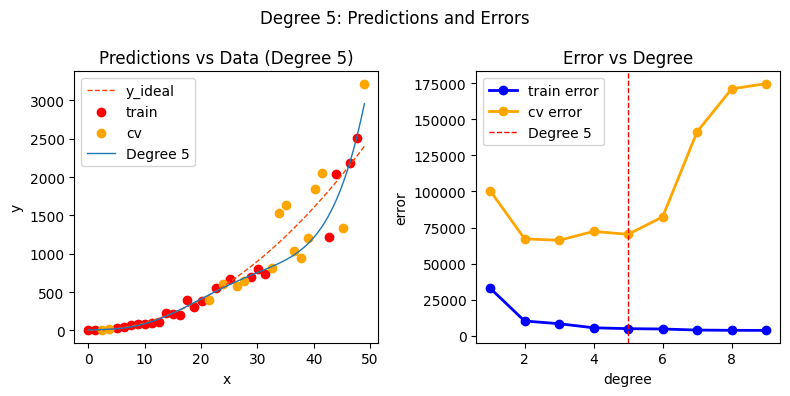

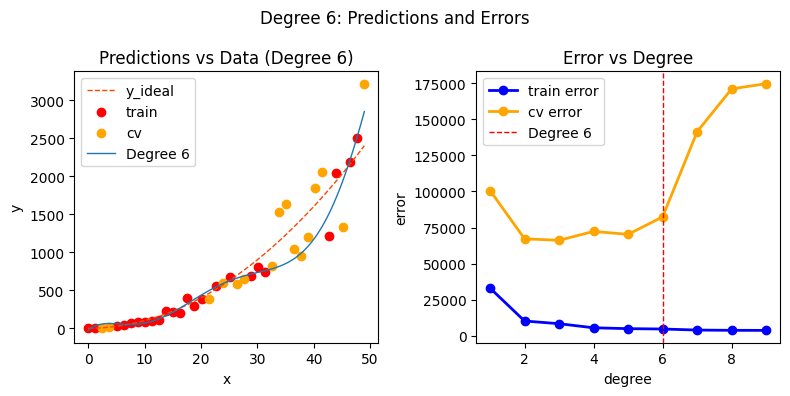

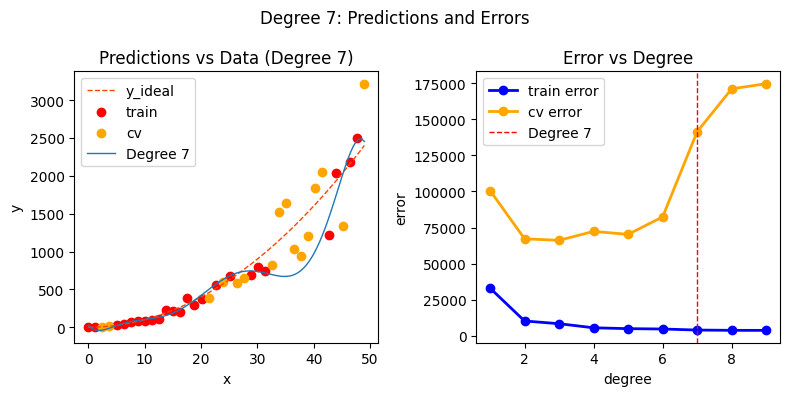

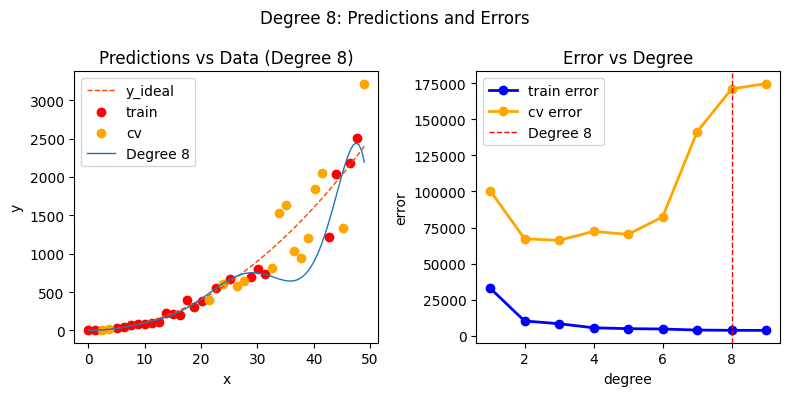

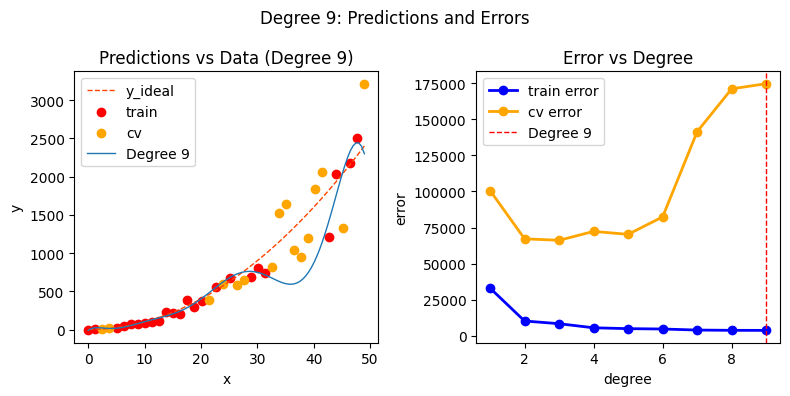

<Figure size 640x480 with 0 Axes>

In [15]:
plt.close("all")
plt_optimal_degree(X_train, y_train, X_cv, y_cv, X_test, y_pred, x_ideal, y_ideal,
                   err_train, err_cv, optimal_degree, max_degree)

# Solution : 
- degree 3, since it gives the lowest cv_err we achieved  !
- at first : both of them have high error -> high bias
- between them : both of them starts to have low error
- at end : train will continue reducing, but cv will get high ! -> high variance

# EXO4 :

In [20]:
lambda_range = np.array([0.0, 1e-6, 1e-5, 1e-4,1e-3,1e-2, 1e-1,1,10,100,1000])
num_steps = len(lambda_range)
degree = 10
err_train = np.zeros(num_steps)
err_cv = np.zeros(num_steps)

y_pred = np.zeros((100,num_steps))  #columns are lines to plot

for i in range(num_steps):
    lambda_= lambda_range[i]

    # CODE STARTS HERE

    poly = PolynomialFeatures(degree=degree, include_bias=False)

    x_train_poly = poly.fit_transform(X_train.reshape(-1,1))
    x_cv_poly = poly.transform(X_cv.reshape(-1,1))

    scalar = StandardScaler()
    x_train_poly = scalar.fit_transform(x_train_poly)
    x_cv_poly = scalar.transform(x_cv_poly)

    model = Ridge(alpha=lambda_)
    model.fit(x_train_poly, y_train)

    yhat_train = model.predict(x_train_poly)
    yhat_cv = model.predict(x_cv_poly)

    err_train[i] = eval_mse(y_train, yhat_train)
    err_cv[i] = eval_mse(y_cv, yhat_cv)

    # CODE ENDS HERE

    x_poly = poly.transform(X_test.reshape(-1,1))
    x_poly = scalar.transform(x_poly)
    y_pred[:,i] = model.predict(x_poly)

optimal_reg_idx = np.argmin(err_cv)
print("optimal lambda =", lambda_range[optimal_reg_idx])

optimal lambda = 0.01


In [17]:
def plt_tune_regularization(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range):
    # Plot each regularization curve in a separate figure
    for i, reg_lambda in enumerate(lambda_range):
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        fig.canvas.toolbar_visible = False
        fig.canvas.header_visible = False
        fig.canvas.footer_visible = False

        # Plot predictions vs data
        ax[0].set_title(f"Predictions vs Data ($\lambda = {reg_lambda}$)", fontsize=12)
        ax[0].set_xlabel("x")
        ax[0].set_ylabel("y")

        ax[0].scatter(X_train, y_train, color="red", label="train")
        ax[0].scatter(X_cv, y_cv, color="orange", label="cv")
        ax[0].plot(x, y_pred[:, i], lw=1, label=f"$\lambda = {reg_lambda}$")
        ax[0].legend()

        # Plot error vs regularization
        ax[1].set_title("Error vs Regularization", fontsize=12)
        ax[1].plot(lambda_range, err_train, label="train error", color="blue")
        ax[1].plot(lambda_range, err_cv, label="cv error", color="orange")
        ax[1].set_xscale('log')
        ax[1].axvline(x=reg_lambda, color="red", linestyle="--", lw=1, label=f"Current $\lambda = {reg_lambda}$")
        ax[1].set_xlabel("Regularization ($\lambda$)")
        ax[1].set_ylabel("Error")
        ax[1].legend()

        fig.suptitle(f"Regularization Analysis ($\lambda = {reg_lambda}$)", fontsize=12)
        plt.tight_layout()
        plt.show()



    fig.suptitle("Tuning Regularization", fontsize=12)
    plt.tight_layout()
    plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:29: SyntaxWarning: invalid escape sequence '\l'
C:\Users\sol\AppData\Local\Temp\ipykernel_8072\2071667080.py:10: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_title(f"Predictions vs Data ($\lambda = {reg_lambda}$)", fontsize=12)
C:\Users\sol\AppData\Local\Temp\ipykernel_8072\2071667080.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax[0].plot(x, y_pred[:, i], lw=1, label=f"$\lambda = {reg_lambda}$")
C:\Users\sol\AppData\Local\Temp\ipykernel_8072\2071667080.py:24: SyntaxWarning: invalid escape sequence '\l'
  ax[1].ax

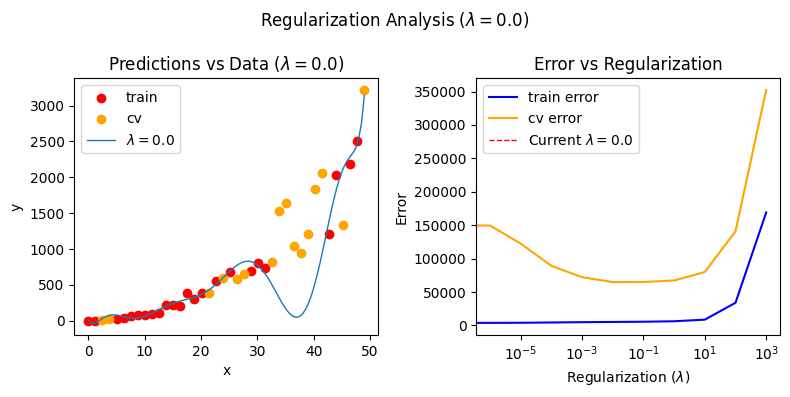

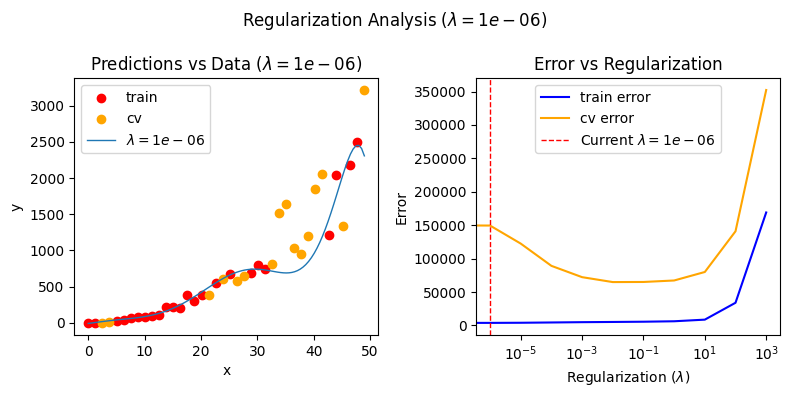

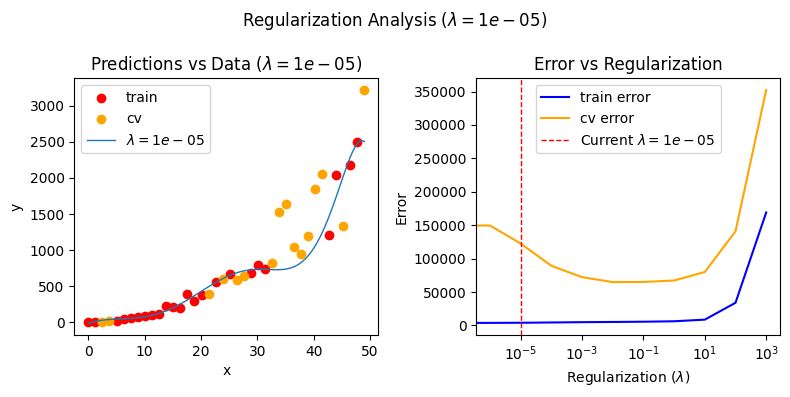

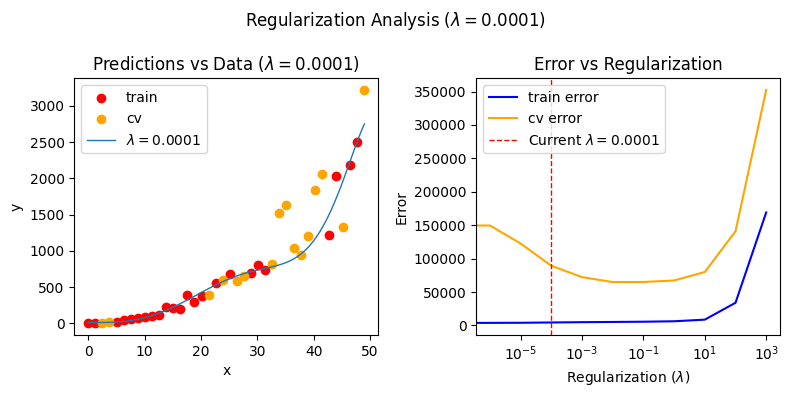

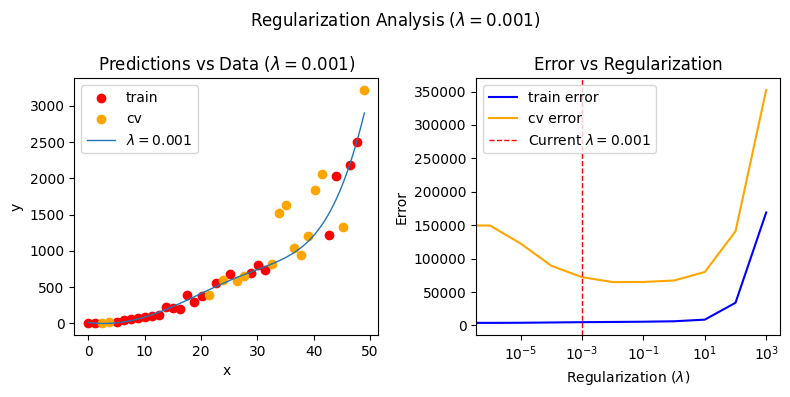

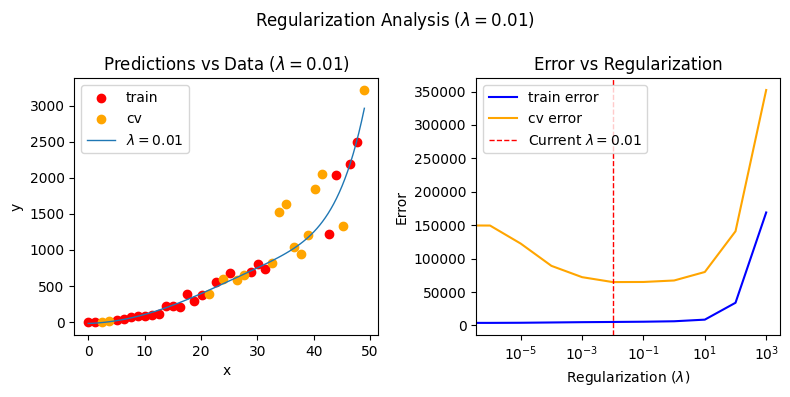

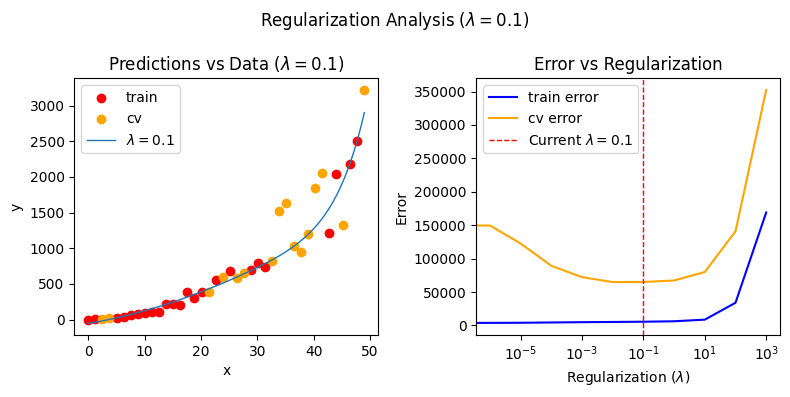

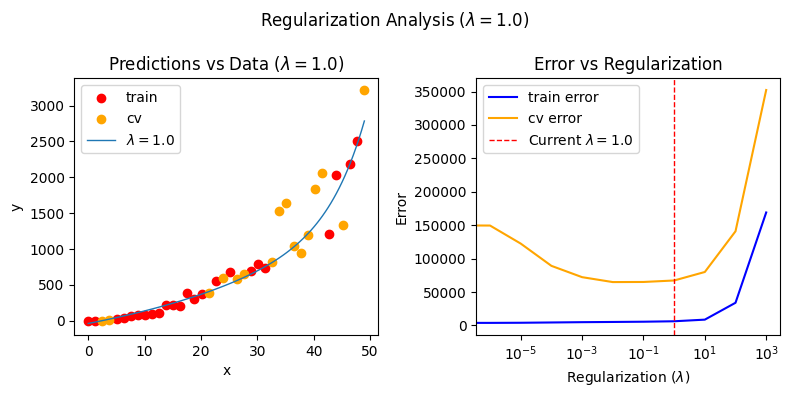

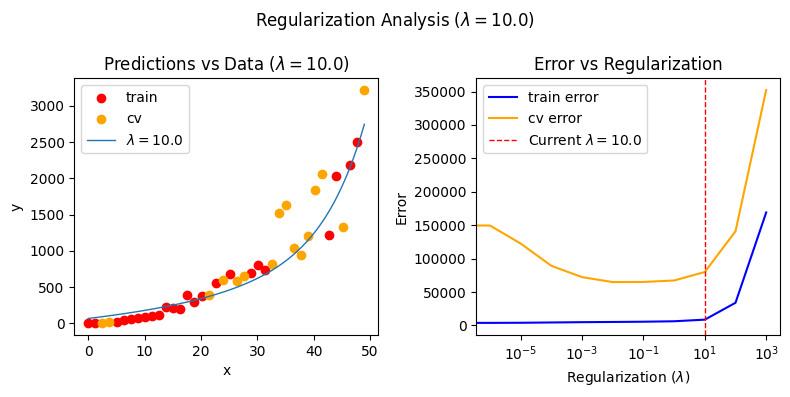

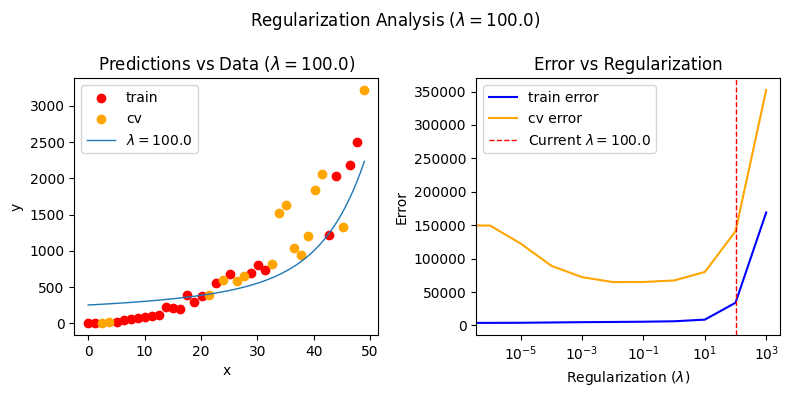

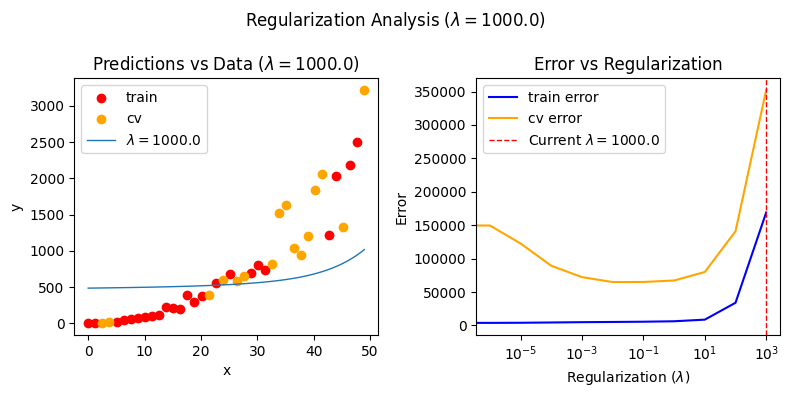

<Figure size 640x480 with 0 Axes>

In [18]:
plt.close("all")
plt_tune_regularization(X_train, y_train, X_cv, y_cv, X_test, y_pred, err_train, err_cv, optimal_reg_idx, lambda_range)

# Solution :
- lambda = 0.01, it gets the lowest cv error
- model starts underfitting from lambda = 1 (from plot)

# EXO5 :

In [22]:
m = 50
m_range = np.array(m*np.arange(1,16))
num_steps = m_range.shape[0]
degree = 16
err_train = np.zeros(num_steps)
err_cv = np.zeros(num_steps)
y_pred = np.zeros((100,num_steps))

for i in range(num_steps):
        X, y, y_ideal, x_ideal = gen_data(m_range[i],5,0.7)
        x = np.linspace(0,int(X.max()),100)
        X_train, X_cv, y_train, y_cv = train_test_split(X,y,test_size=0.40, random_state=1)

        # CODE STARTS HERE

        poly = PolynomialFeatures(degree=degree, include_bias=False)

        x_train_poly = poly.fit_transform(X_train.reshape(-1,1))
        x_cv_poly = poly.transform(X_cv.reshape(-1,1))

        scalar = StandardScaler()
        x_train_poly = scalar.fit_transform(x_train_poly)
        x_cv_poly = scalar.transform(x_cv_poly)

        model = LinearRegression()
        model.fit(x_train_poly, y_train)

        yhat_train = model.predict(x_train_poly)
        yhat_cv = model.predict(x_cv_poly)

        err_train[i] = eval_mse(y_train, yhat_train)
        err_cv[i] = eval_mse(y_cv, yhat_cv)

        # CODE ENDS HERE

        x_poly = poly.transform(X_test.reshape(-1,1))
        x_poly = scalar.transform(x_poly)
        y_pred[:,i] = model.predict(x_poly)


In [23]:
def plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree):
    # Plot each m in a separate figure
    for i, m in enumerate(m_range):
        fig, ax = plt.subplots(1, 2, figsize=(8, 4))
        fig.canvas.toolbar_visible = False
        fig.canvas.header_visible = False
        fig.canvas.footer_visible = False

        # Plot predictions vs data
        ax[0].set_title(f"Predictions vs Data ($m = {m}$)", fontsize=12)
        ax[0].set_xlabel("x")
        ax[0].set_ylabel("y")

        ax[0].scatter(X_train, y_train, color="red", s=3, label="train", alpha=0.4)
        ax[0].scatter(X_cv, y_cv, color="orange", s=3, label="cv", alpha=0.4)
        ax[0].plot(x, y_pred[:, i], lw=1, label=f"$m = {m}$")
        ax[0].legend(loc='upper left')
        ax[0].text(0.05, 0.5, f"degree = {degree}", fontsize=10, ha='left', transform=ax[0].transAxes, color="blue")

        # Plot error vs number of examples
        ax[1].set_title("Error vs Number of Examples", fontsize=12)
        ax[1].plot(m_range, err_train, label="train error", color="blue")
        ax[1].plot(m_range, err_cv, label="cv error", color="orange")
        ax[1].axvline(x=m, color="red", linestyle="--", lw=1, label=f"Current $m = {m}$")
        ax[1].set_xlabel("Number of Examples (m)")
        ax[1].set_ylabel("Error")
        ax[1].legend()

        fig.suptitle(f"Tuning Number of Examples ($m = {m}$)", fontsize=12)
        plt.tight_layout()
        plt.show()


    fig.suptitle("Tuning Number of Examples", fontsize=12)
    plt.tight_layout()
    plt.show()

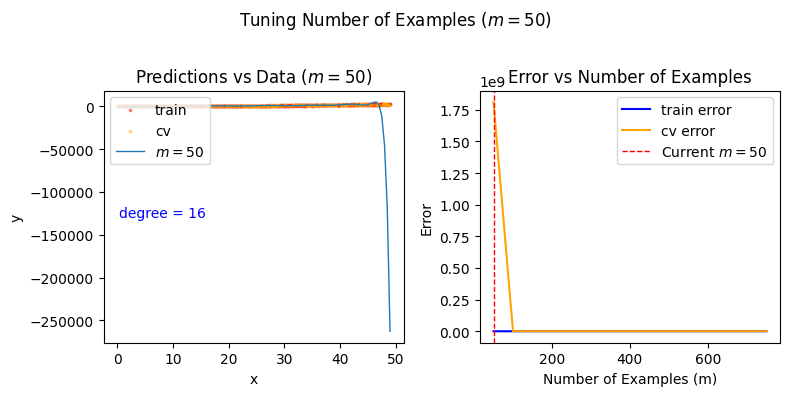

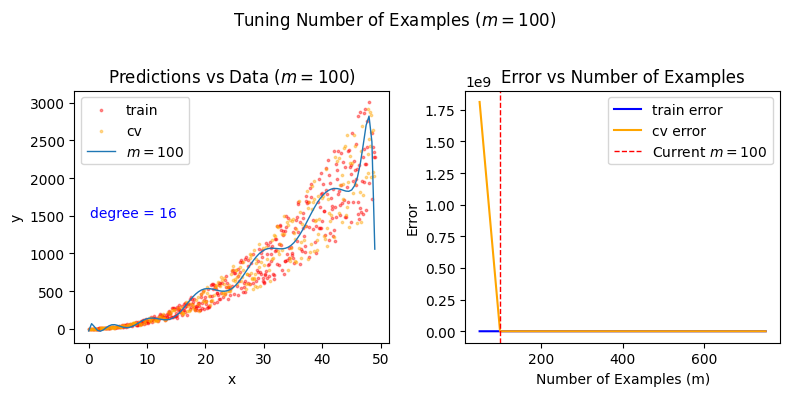

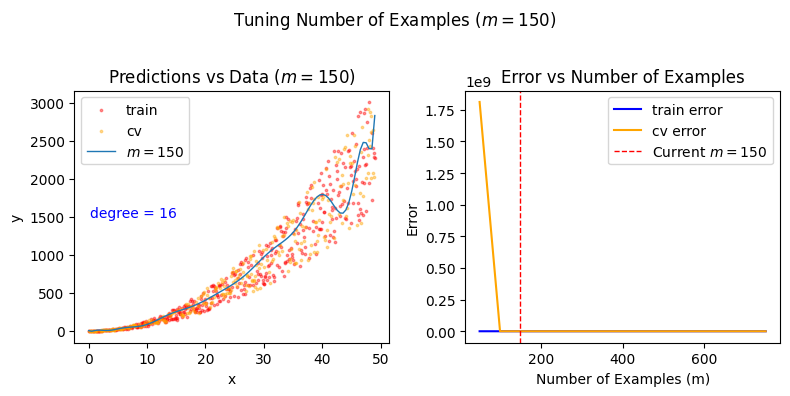

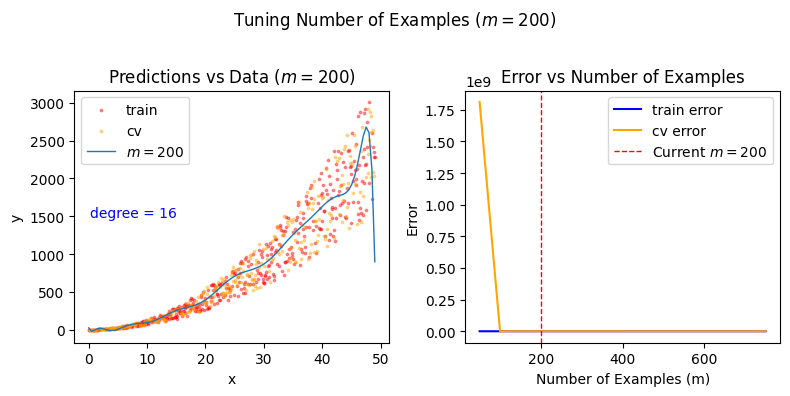

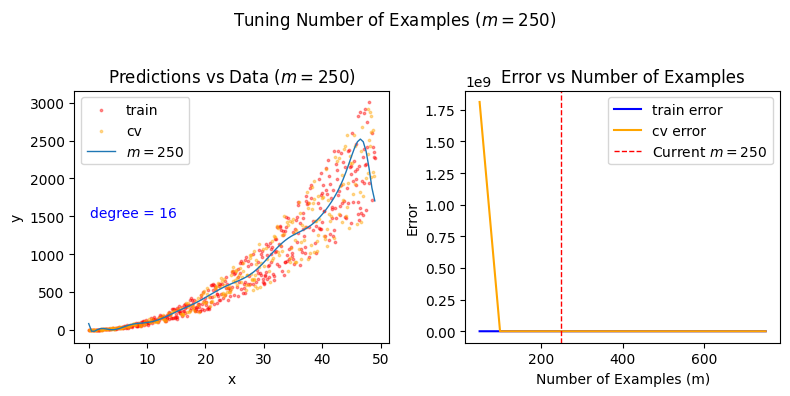

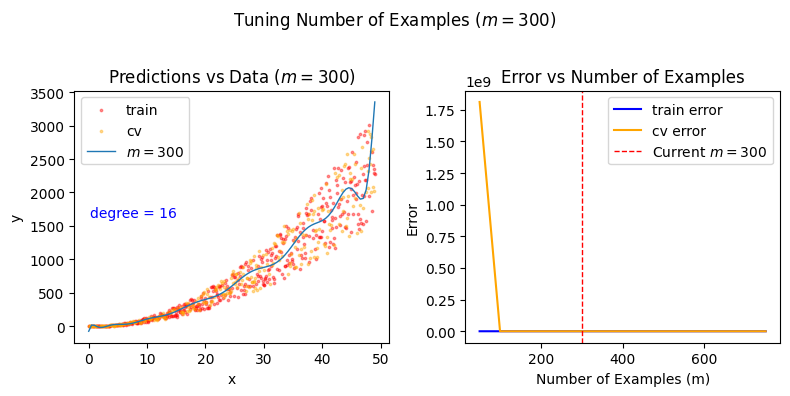

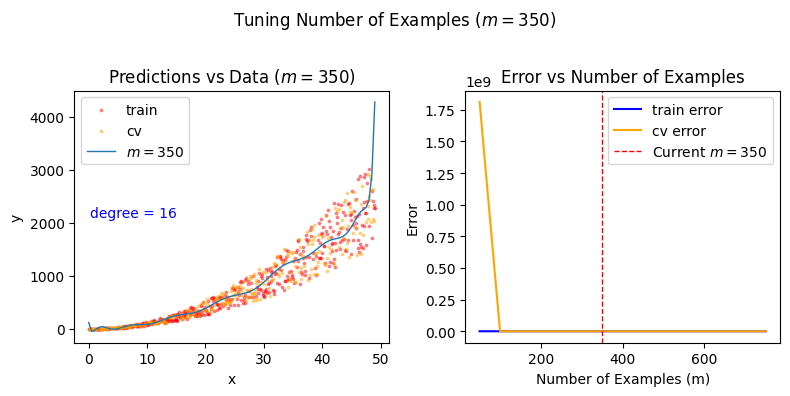

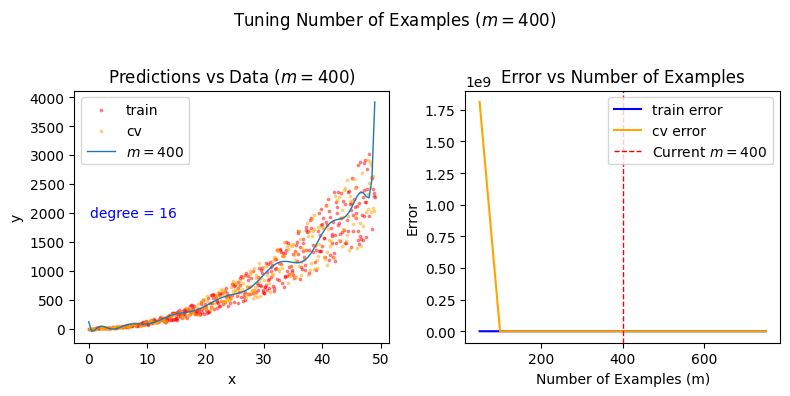

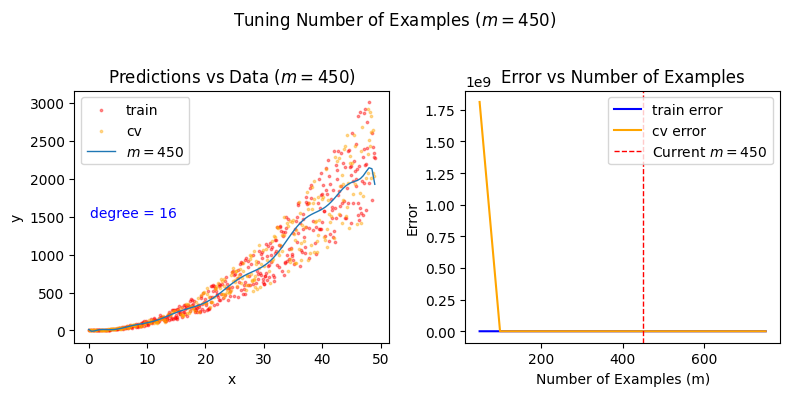

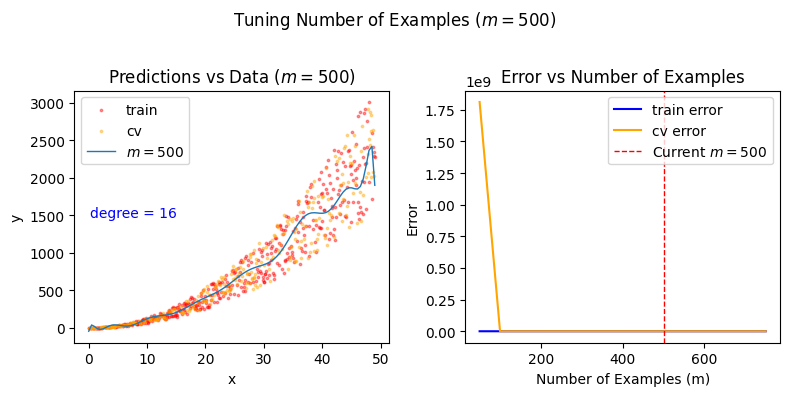

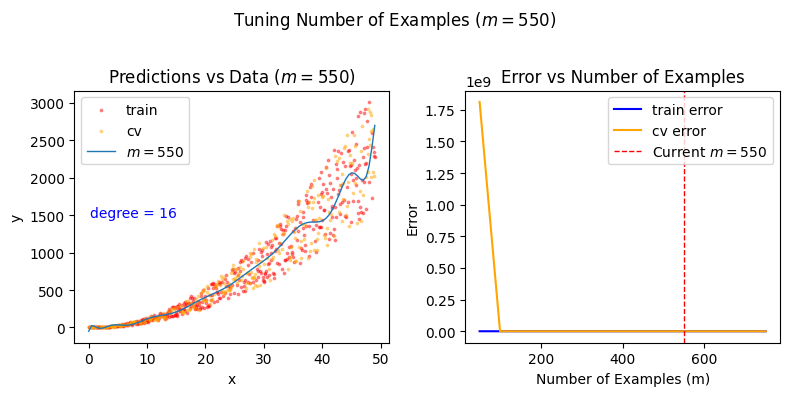

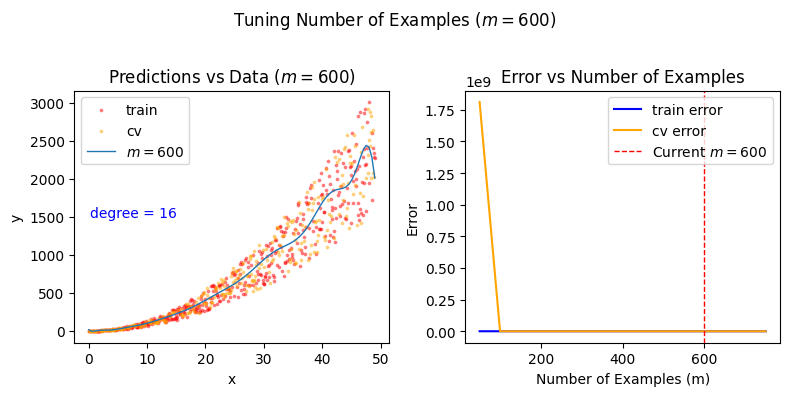

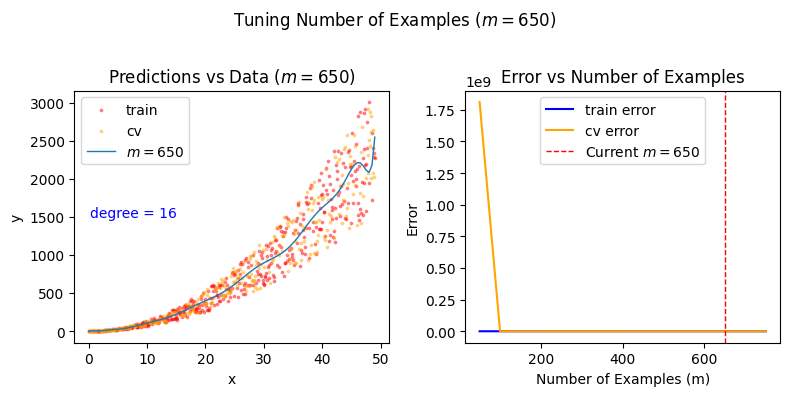

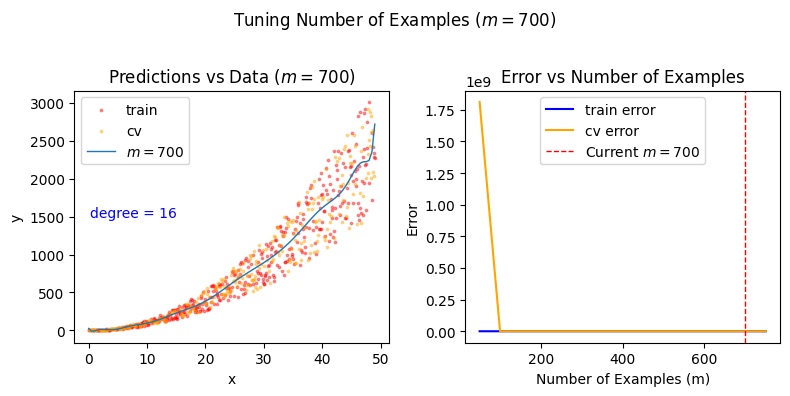

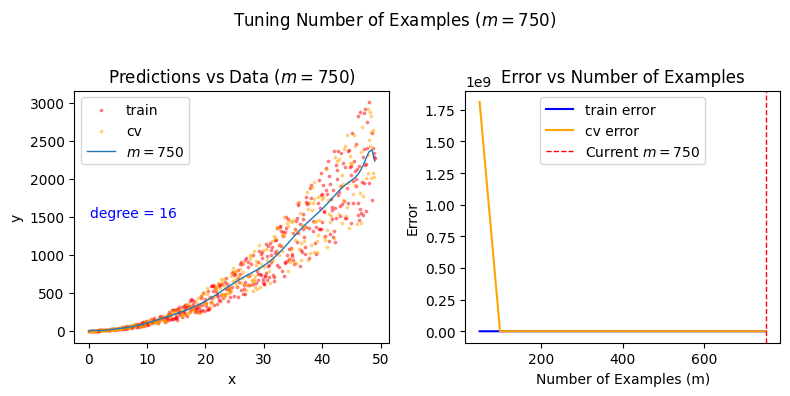

<Figure size 640x480 with 0 Axes>

In [24]:
plt_tune_m(X_train, y_train, X_cv, y_cv, x, y_pred, err_train, err_cv, m_range, degree)

# Solution :
- the more the sample size we add :
- cv err will reduce
- train err will increase ?

In [4]:
from sklearn.datasets import make_blobs
def gen_blobs():
    classes = 6
    m = 800
    std = 0.4
    centers = np.array([[-1, 0], [1, 0], [0, 1], [0, -1],  [-2,1],[-2,-1]])
    X, y = make_blobs(n_samples=m, centers=centers, cluster_std=std, random_state=2, n_features=2)
    return (X, y, centers, classes, std)

In [5]:
# Generate and split data set
X, y, centers, classes, std = gen_blobs()

# split the data. Large CV population for demonstration
X_train, X_, y_train, y_ = train_test_split(X,y,test_size=0.50, random_state=1)
X_cv, X_test, y_cv, y_test = train_test_split(X_,y_,test_size=0.20, random_state=1)
print("X_train.shape:", X_train.shape, "X_cv.shape:", X_cv.shape, "X_test.shape:", X_test.shape)

X_train.shape: (400, 2) X_cv.shape: (320, 2) X_test.shape: (80, 2)


# EXO6 :

In [13]:
def eval_cat_err(y, yhat):
  
  m = y.shape[0]
  cerr = np.sum(y != yhat) / m

  return cerr

In [29]:
y_hat = np.array([1, 2, 0])
y_tmp = np.array([1, 2, 3])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.333" )
y_hat = np.array([[1], [2], [0], [3]])
y_tmp = np.array([[1], [2], [1], [3]])
print(f"categorization error {np.squeeze(eval_cat_err(y_hat, y_tmp)):0.3f}, expected:0.250" )

categorization error 0.333, expected:0.333
categorization error 0.250, expected:0.250


# EXO7 :

In [30]:
tf.random.set_seed(1234)
model = Sequential(
    [
        ### START CODE HERE ###
        Dense(120, activation='relu', name="L1"),
        Dense(40, activation='relu', name="L2"),
        Dense(6, activation='linear', name="L3")
        ### END CODE HERE ###
    ], name="Complex"
)
model.compile(
    ### START CODE HERE ###
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
    ### END CODE HERE ###
)

In [31]:
model.fit(
    X_train, y_train,
    epochs=1000
)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.1552
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4474  
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.3675
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3038
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2545  
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2473
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2477  
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2349  
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2212  
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2205  
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2189
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2184  
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2132
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2116  
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━

In [32]:
model.summary()

Model: "Complex"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (63.83 KB)

 Trainable params: 5,446 (21.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (42.56 KB)

In [33]:
import matplotlib as mpl

dkcolors = plt.cm.Paired((1,3,7,9,5,11))
ltcolors = plt.cm.Paired((0,2,6,8,4,10))
dkcolors_map = mpl.colors.ListedColormap(dkcolors)
ltcolors_map = mpl.colors.ListedColormap(ltcolors)

def plt_mc_data(ax, X, y, classes,  class_labels=None, map=plt.cm.Paired, legend=False,size=50, m='o'):
    for i in range(classes):
        idx = np.where(y == i)
        col = len(idx[0])*[i]
        label = class_labels[i] if class_labels else "c{}".format(i)
        ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
                    c=col, vmin=0, vmax=map.N, cmap=map,
                    s=size, label=label)
    if legend: ax.legend()
    ax.axis('equal')

def plot_cat_decision_boundary(ax, X,predict , class_labels=None, legend=False, vector=True, color='g', lw = 1):

    # create a mesh to points to plot
    pad = 0.5
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    h = max(x_max-x_min, y_max-y_min)/200
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    points = np.c_[xx.ravel(), yy.ravel()]
    #print("points", points.shape)
    #make predictions for each point in mesh
    if vector:
        Z = predict(points)
    else:
        Z = np.zeros((len(points),))
        for i in range(len(points)):
            Z[i] = predict(points[i].reshape(1,2))
    Z = Z.reshape(xx.shape)

    #contour plot highlights boundaries between values - classes in this case
    ax.contour(xx, yy, Z, colors=color, linewidths=lw)
    ax.axis('tight')

def plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle=""):
    #plot the decison boundary.
    fig,ax = plt.subplots(1,2, figsize=(8,4))
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False
    plot_cat_decision_boundary(ax[0], X_train, model_predict,  vector=True)
    ax[0].set_title("training data", fontsize=14)

    #add the original data to the decison boundary
    plt_mc_data(ax[0], X_train,y_train, classes, map=dkcolors_map, legend=True, size=75)
    ax[0].set_xlabel('x0') ; ax[0].set_ylabel("x1");

    plot_cat_decision_boundary(ax[1], X_train, model_predict,  vector=True)
    ax[1].set_title("cross-validation data", fontsize=14)
    plt_mc_data(ax[1], X_cv,y_cv, classes,
                map=ltcolors_map, legend=True, size=100, m='<')
    ax[1].set_xlabel('x0') ; ax[1].set_ylabel("x1");
    fig.suptitle(suptitle,fontsize = 12)
    plt.show()

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


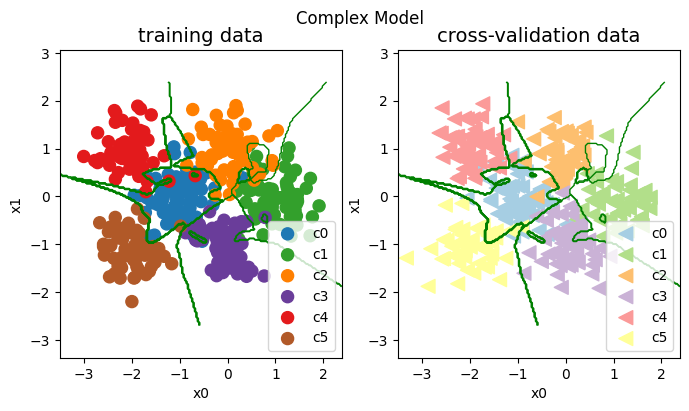

In [34]:
#make a model for plotting routines to call
model_predict = lambda Xl: np.argmax(tf.nn.softmax(model.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict,X_train,y_train, classes, X_cv, y_cv, suptitle="Complex Model")

In [35]:
training_cerr_complex = eval_cat_err(y_train, model_predict(X_train))
cv_cerr_complex = eval_cat_err(y_cv, model_predict(X_cv))
print(f"categorization error, training, complex model: {training_cerr_complex:0.3f}")
print(f"categorization error, cv,       complex model: {cv_cerr_complex:0.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
categorization error, training, complex model: 0.003
categorization error, cv,       complex model: 0.100


# NOTE : 
- this is **not overfitting** right ? both of train and cv err are low

# EXO8 :

In [36]:
tf.random.set_seed(1234)
model_s = Sequential(
    [
        ### START CODE HERE ###
        Dense(6, activation='relu'),
        Dense(6, activation='linear')
        ### END CODE HERE ###
    ], name = "Simple"
)
model_s.compile(
    ### START CODE HERE ###
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
    ### START CODE HERE ###
)

In [38]:
model_s.fit(
    X_train,y_train,
    epochs=1000
)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8913
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.4840
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2300
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0456
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9035
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7883 
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6914  
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6083 
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5373 
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4796  
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4350  
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4012  
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3758  
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3560 
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━

In [39]:
model_s.summary()

Model: "Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182 (732.00 B)

 Trainable params: 60 (240.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 122 (492.00 B)

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


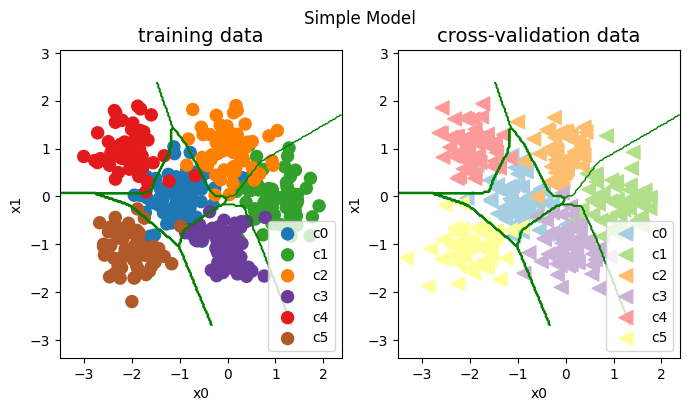

In [40]:
#make a model for plotting routines to call
model_predict_s = lambda Xl: np.argmax(tf.nn.softmax(model_s.predict(Xl)).numpy(),axis=1)
plt_nn(model_predict_s,X_train,y_train, classes, X_cv, y_cv, suptitle="Simple Model")

In [41]:
training_cerr_simple = eval_cat_err(y_train, model_predict_s(X_train))
cv_cerr_simple = eval_cat_err(y_cv, model_predict_s(X_cv))
print(f"categorization error, training, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
categorization error, training, simple model, 0.058, complex model: 0.003
categorization error, cv,       simple model, 0.075, complex model: 0.100


# EXO9 :

In [58]:
tf.random.set_seed(1234)
model_r = Sequential(
    [
        Dense(120, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        Dense(40, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.1)),
        Dense(6, activation='linear')
    ],
    name="Complex_Regularized"
)

model_r.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01)
)

In [59]:
model_r.fit(
    X_train, y_train,
    epochs=1000
)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.4440
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6651 
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3377  
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1178
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.0211
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9779  
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9237  
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8758  
Epoch 9/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8384
Epoch 10/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8125   
Epoch 11/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7966
Epoch 12/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7755 
Epoch 13/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7560 
Epoch 14/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7373
Epoch 15/1000
13/13 ━━━━━━━━━━━━━━━━━━

In [60]:
model_r.summary()

Model: "Complex_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 120)            │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         4,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           246 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,340 (63.83 KB)

 Trainable params: 5,446 (21.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,894 (42.56 KB)

1082/1082 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
1082/1082 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


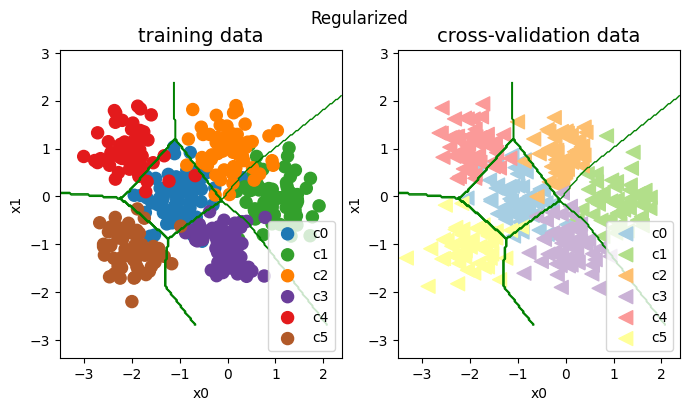

In [61]:
#make a model for plotting routines to call
model_predict_r = lambda Xl: np.argmax(tf.nn.softmax(model_r.predict(Xl)).numpy(),axis=1)

plt_nn(model_predict_r, X_train,y_train, classes, X_cv, y_cv, suptitle="Regularized")

In [62]:
training_cerr_reg = eval_cat_err(y_train, model_predict_r(X_train))
cv_cerr_reg = eval_cat_err(y_cv, model_predict_r(X_cv))
test_cerr_reg = eval_cat_err(y_test, model_predict_r(X_test))
print(f"categorization error, training, regularized: {training_cerr_reg:0.3f}, simple model, {training_cerr_simple:0.3f}, complex model: {training_cerr_complex:0.3f}" )
print(f"categorization error, cv,       regularized: {cv_cerr_reg:0.3f}, simple model, {cv_cerr_simple:0.3f}, complex model: {cv_cerr_complex:0.3f}" )

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
categorization error, training, regularized: 0.070, simple model, 0.058, complex model: 0.003
categorization error, cv,       regularized: 0.069, simple model, 0.075, complex model: 0.100


# find best lambda value :

In [6]:
tf.random.set_seed(1234)
lambdas = [0.0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
models=[None] * len(lambdas)
for i in range(len(lambdas)):
    lambda_ = lambdas[i]
    models[i] =  Sequential(
        [
            Dense(120, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(40, activation = 'relu', kernel_regularizer=tf.keras.regularizers.l2(lambda_)),
            Dense(classes, activation = 'linear')
        ]
    )
    models[i].compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.Adam(0.01),
    )

    models[i].fit(
        X_train,y_train,
        epochs=200
    )
    print(f"Finished lambda = {lambda_}")


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.1045
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4169  
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3528 
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2995 
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2528 
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2521  
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2473
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2272
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2235
Epoch 10/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2235
Epoch 11/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2216  
Epoch 12/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2167 
Epoch 13/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2181 
Epoch 14/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2140 
Epoch 15/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step -

In [10]:
def plot_iterate(lambdas, models, X_train, y_train, X_cv, y_cv):
    err_train = np.zeros(len(lambdas))
    err_cv = np.zeros(len(lambdas))

    for i, model in enumerate(models):
        # predictions on train and cv
        yhat_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
        yhat_cv = np.argmax(model.predict(X_cv, verbose=0), axis=1)

        # classification errors
        err_train[i] = eval_cat_err(y_train, yhat_train)
        err_cv[i] = eval_cat_err(y_cv, yhat_cv)

        print(f"lambda={lambdas[i]:0.3f} | train_err={err_train[i]:0.4f} | cv_err={err_cv[i]:0.4f}")

    # best lambda = one with smallest cv error
    best_idx = np.argmin(err_cv)
    print(f"\nBest lambda = {lambdas[best_idx]}")

    # plotting
    plt.figure(figsize=(8,5))
    plt.plot(lambdas, err_train, marker='o', label='train error')
    plt.plot(lambdas, err_cv, marker='o', label='cv error')
    plt.xscale('log')
    plt.xlabel('lambda')
    plt.ylabel('classification error')
    plt.title('Train and CV error vs lambda')
    plt.legend()
    plt.grid(True)
    plt.show()

    return best_idx, err_train, err_cv

lambda=0.000 | train_err=0.0300 | cv_err=0.0875
lambda=0.001 | train_err=0.0550 | cv_err=0.0875
lambda=0.010 | train_err=0.0675 | cv_err=0.0719
lambda=0.050 | train_err=0.0650 | cv_err=0.0594
lambda=0.100 | train_err=0.0900 | cv_err=0.0750
lambda=0.200 | train_err=0.0925 | cv_err=0.0781
lambda=0.300 | train_err=0.0950 | cv_err=0.0750

Best lambda = 0.05


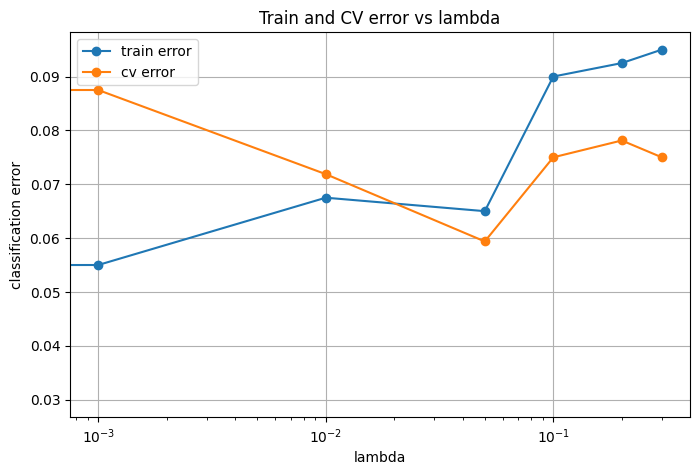

In [14]:
best_idx, err_train, err_cv = plot_iterate(
    lambdas, models, X_train, y_train, X_cv, y_cv
)